In [2]:
import Pkg

# Activate your MyProject environment
Pkg.activate(raw"C:\Users\HP\Code\Master thesis\Model\MyJulia19")

# Confirm the active environment
println("Active environment: ", Base.active_project())

  Activating project at `C:\Users\HP\Code\Master thesis\Model\MyJulia19`


Active environment: C:\Users\HP\Code\Master thesis\Model\MyJulia19\Project.toml


In [141]:
using Random, Plots
using Zygote, ForwardDiff
using OrdinaryDiffEq, DiffEqSensitivity
using LinearAlgebra
using Statistics
using ProgressBars, Printf
using Flux
using Flux.Optimise: update!
using Flux.Losses: mae, mse
using BSON: @save, @load
using DelimitedFiles
using YAML
using MLFlowClient

In [143]:
pwd()

"C:\\Users\\HP\\Code\\Master thesis\\Model\\Xylan\\Catalyst model"

In [145]:
ENV["GKSwstype"] = "100"

"100"

In [147]:
# Create MLFlow instance
mlf = MLFlow("http://localhost:5000/api")

# Initiate new experiment

# experiment_id = createexperiment(mlf, "Xylan Final New")

mlf_exp = getexperimentbyname(mlf, "Xylan Final New")
experiment_id = mlf_exp.experiment_id

# Create a run in the new experiment

exprun = createrun(mlf, experiment_id)
# old_run_id = "11a6f4d80ca24fb4976f3f924913a1ca"  # from UI
# exprun = getrun(mlf, old_run_id)


Run(
    info = RunInfo(
    run_id = "bfaffdc5615b4cc38e1027b318ed04d9", 
    run_name = "painted-bear-939", 
    experiment_id = "226066302387340575", 
    status = MLFlowClient.RunStatus.RUNNING, 
    start_time = 0, 
    end_time = nothing, 
    artifact_uri = "mlflow-artifacts:/226066302387340575/bfaffdc5615b4cc38e1027b318ed04d9/artifacts", 
    lifecycle_stage = "active"
), 
    data = RunData(
    metrics = Metric[], 
    params = Param[], 
    tags = Tag[Tag(
    key = "mlflow.runName", 
    value = "painted-bear-939"
)]
), 
    inputs = RunInputs(
    dataset_inputs = DatasetInput[], 
    model_inputs = ModelInput[]
), 
    outputs = MLFlowClient.RunOutputs(
    model_outputs = ModelOutput[]
)
)

In [152]:
conf = YAML.load_file("./config.yaml")

Dict{Any, Any} with 15 entries:
  "lr_max"        => 0.005
  "grad_max"      => 100.0
  "maxiters"      => 10000
  "n_epoch"       => 2500
  "lr_min"        => 1.0e-5
  "is_restart"    => false
  "lr_decay"      => 0.2
  "lr_decay_step" => 500
  "nc"            => 1
  "expr_name"     => "Xyl-6s5r1c-06"
  "nr"            => 5
  "n_plot"        => 10
  "ns"            => 6
  "lb"            => 1.0e-8
  "w_decay"       => 1.0e-8

In [154]:
expr_name = conf["expr_name"]
fig_path = string("./results_catalyst/", expr_name, "/figs")
ckpt_path = string("./results_catalyst/", expr_name, "/checkpoint")
config_path = "./results_catalyst/$expr_name/config.yaml"

is_restart = Bool(conf["is_restart"])
ns = Int64(conf["ns"])
nr = Int64(conf["nr"])
nc = Int64(conf["nc"])
nss = Int64(conf["ns"]) - Int64(conf["nc"])
lb = Float64(conf["lb"])
n_epoch = Int64(conf["n_epoch"])
n_plot = Int64(conf["n_plot"])
grad_max = Float64(conf["grad_max"])
maxiters = Int64(conf["maxiters"])

lr_max = Float64(conf["lr_max"])
lr_min = Float64(conf["lr_min"])
lr_decay = Float64(conf["lr_decay"])
lr_decay_step = Int64(conf["lr_decay_step"])
w_decay = Float64(conf["w_decay"])

1.0e-8

In [156]:
llb = lb;
global p_cutoff = -1.0
const l_exp = 1:18
n_exp = length(l_exp)

l_train = []
l_val = []
for i = 1:n_exp
    j = l_exp[i]
    if !(j in [7, 8, 9, 10, 11, 12])
        push!(l_train, i)
    else
        push!(l_val, i)
    end
end

opt = Flux.Optimiser(
 ExpDecay(lr_max, lr_decay, length(l_train) * lr_decay_step, lr_min),
 ADAMW(lr_max, (0.9, 0.999), w_decay),
);

#opt = Flux.Optimise.ADAMW(lr_max,(0.9,0.999), w_decay)

In [157]:
l_train, l_val, n_exp

(Any[1, 2, 3, 4, 5, 6, 13, 14, 15, 16, 17, 18], Any[7, 8, 9, 10, 11, 12], 18)

In [158]:
if !is_restart
    if ispath(fig_path)
        rm(fig_path, recursive = true)
    end
    if ispath(ckpt_path)
        rm(ckpt_path, recursive = true)
    end
end

if ispath("./results_catalyst") == false
    mkdir("./results_catalyst")
end

if ispath("./results_catalyst/$expr_name") == false
    mkdir("./results_catalyst/$expr_name")
end

if ispath(fig_path) == false
    mkdir(fig_path)
    mkdir(string(fig_path, "/conditions"))
end

if ispath(ckpt_path) == false
    mkdir(ckpt_path)
end

cp("./config.yaml", config_path; force=true)

"./results_catalyst/Xyl-6s5r1c-06/config.yaml"

In [161]:
function load_exp(filename)
    exp_data = readdlm(filename)
    index = indexin(unique(exp_data[:, 1]), exp_data[:, 1])
    exp_data = exp_data[index, :]
    exp_data[:, 3] = exp_data[:, 3] / maximum(exp_data[:, 3])

    # ✅ NEW: enforce monotone decrease — remove TGA artefact
    for i in 2:size(exp_data, 1)
        if exp_data[i, 3] > exp_data[i-1, 3]
            exp_data[i, 3] = exp_data[i-1, 3]
        end
    end
    return exp_data
end

load_exp (generic function with 1 method)

In [162]:
l_exp_data = [];
l_exp_info = zeros(Float64, length(l_exp), 3);
for (i_exp, value) in enumerate(l_exp)
    # filename = string("data_cat/expdata_no", string(value), ".txt")
    filename = string("data_cat_new/expdata_no", string(value), ".txt")

    exp_data = Float64.(load_exp(filename))

    #exp_data = exp_data[1:80, :]
    
    # if value == 22
    #     exp_data = exp_data[1:90, :]
    # elseif value == 23
    #     exp_data = exp_data[1:100, :]
    # elseif value == 24
    #     exp_data = exp_data[1:100, :]
    #end

    push!(l_exp_data, exp_data)
    l_exp_info[i_exp, 1] = exp_data[1, 2] # initial temperature, K
end
# l_exp_info[:, 2] = readdlm("data_cat/beta.txt")[l_exp];
# l_exp_info[:, 3] = (readdlm("data_cat/cata_conc.txt")[l_exp]);

l_exp_info[:, 2] = readdlm("data_cat_new/beta.txt")[l_exp];
l_exp_info[:, 3] = (readdlm("data_cat_new/cata_conc.txt")[l_exp]);

In [164]:
l_exp_data[1]

149×3 Matrix{Float64}:
     0.0    373.15   1.0
   199.95   382.267  0.993163
   427.993  391.91   0.986446
   634.078  400.218  0.979934
   923.632  411.842  0.973866
   974.672  413.877  0.966827
  1099.6    418.918  0.96614
  1435.29   432.812  0.961874
  1697.62   443.825  0.95929
  1911.22   452.799  0.956111
  2206.79   465.226  0.952973
  2405.48   473.534  0.94619
  2475.94   476.526  0.940474
     ⋮               
  9245.89   758.518  0.0690795
  9579.0    772.41   0.0631992
  9879.0    784.87   0.0579664
 10136.0    795.52   0.0513316
 10332.1    803.614  0.0446037
 10590.7    814.402  0.0379807
 10852.1    825.295  0.0313182
 11111.0    836.151  0.0248713
 11365.5    846.685  0.0201554
 11592.0    856.067  0.0134799
 11826.1    865.834  0.00676854
 12002.0    873.15   0.0

In [165]:
l_exp_info

18×3 Matrix{Float64}:
 373.15   2.5  0.0
 373.15   2.5  0.0
 373.15   2.5  0.0
 373.17   2.5  0.01
 373.16   2.5  0.01
 373.17   2.5  0.01
 373.23   5.0  0.0
 373.25   5.0  0.0
 373.17   5.0  0.0
 373.16   5.0  0.01
 373.18   5.0  0.01
 373.22   5.0  0.01
 373.41  10.0  0.0
 373.23  10.0  0.0
 373.19  10.0  0.0
 373.36  10.0  0.01
 373.32  10.0  0.01
 373.23  10.0  0.01

In [167]:
Random.seed!(42)
np = nr * (ns + nc + 3) + 1
p = randn(Float64, np) .* 5.e-2;
p[1:nr] .+= 0.8;  # w_lnA
#p[nr*(nss+1)+1:nr*(ns+1)].*= 10            #w_cat_in
p[nr*(ns+1)+1:nr*(ns+nc+1)] .= 0         #w_cat_out
p[nr*(ns+nc+1)+1:nr*(ns+nc+2)] .+= 0.8;  # w_Ea
p[nr*(ns+nc+2)+1:nr*(ns+nc+3)] .+= 0.1;  # w_b
p[end] = 0.1;  #slope

In [168]:
function p2vec(p)
    slope = p[end] .* 1.e1
    w_b = p[1:nr] .* (slope * 10.0)
    w_b = clamp.(w_b, -23, 50)

    w_out = reshape(p[nr+1:nr*(nss+1)], nss, nr)
    @. w_out[1, :] = clamp(w_out[1, :], -3.0, 0.0)
    @. w_out[end, :] = clamp(abs(w_out[end, :]), 0.0, 3.0)

    if p_cutoff > 0.0
        w_out[findall(abs.(w_out) .< p_cutoff)] .= 0.0
    end

    w_out[nss-1:nss-1, :] .=
        -sum(w_out[1:nss-2, :], dims = 1) .- sum(w_out[nss:nss, :], dims = 1)

    w_cat_in = p[nr*(nss+1)+1:nr*(ns+1)]
    w_cat_out = p[nr*(ns+1)+1:nr*(ns+nc+1)]*0
    
    #w_cat_out = - sign.(w_cat_in) .* abs.(w_cat_out);
    w_cat_in = abs.(w_cat_in)
    
    
    if p_cutoff > 0.0
        w_cat_in[findall(abs.(w_cat_in) .< p_cutoff)] .= 0.0
    end
    
    w_in_Ea = abs.(p[nr*(ns+nc+1)+1:nr*(ns+nc+2)].* (slope * 100.0))
    w_in_Ea = clamp.(w_in_Ea, 80.0, 200.0)

    w_in_b = abs.(p[nr*(ns+nc+2)+1:nr*(ns+nc+3)])


    w_in = vcat(clamp.(-w_out, 0.0, 3.0), w_cat_in', w_in_Ea', w_in_b')
    w_out = vcat(w_out, w_cat_out')
    
    return w_in, w_b, w_out
end

p2vec (generic function with 1 method)

In [169]:
# expr_name1 = "ML-5s4r1c-01"
# ckpt_path1 = string("./results_catalyst/", expr_name1, "/checkpoint")
# @load string(ckpt_path1, "/mymodel.bson") p

In [170]:
function display_p(p)
    w_in, w_b, w_out = p2vec(p)
    println("\n species (column) reaction (row)")
    println("w_in | w_cat_in | Ea | b | lnA | w_out | w_cat_out")
    show(stdout, "text/plain", round.(hcat(w_in', w_b, w_out'), digits = 2))
    # println("\n w_out")
    # show(stdout, "text/plain", round.(w_out', digits=3))
    println("\n")
end
display_p(p)


 species (column) reaction (row)
w_in | w_cat_in | Ea | b | lnA | w_out | w_cat_out
5×15 Matrix{Float64}:
 -0.0   0.04  0.07  0.0   0.0  0.01  84.83  0.06  7.82   0.0   -0.04  -0.07   0.11  0.0   0.0
  0.04  0.0   0.0   0.05  0.0  0.06  81.61  0.05  8.13  -0.04   0.04   0.02  -0.05  0.03  0.0
 -0.0   0.0   0.06  0.0   0.0  0.1   82.02  0.09  7.84   0.0   -0.0   -0.06   0.06  0.0   0.0
  0.07  0.07  0.0   0.0   0.0  0.04  80.0   0.09  7.84  -0.07  -0.07   0.07   0.0   0.08  0.0
 -0.0   0.0   0.0   0.09  0.0  0.02  80.0   0.08  8.41   0.0    0.04   0.01  -0.09  0.03  0.0



In [171]:
function getsampletemp(t, T0, beta, t0 = 0.0)
    
    T = clamp.((T0 + beta / 60 * (t - t0)), 0, 873.15)   # K/min to K/s

    return T
end

getsampletemp (generic function with 2 methods)

In [172]:
const R = -1.0 / 8.314e-3  # universal gas constant, kJ/mol*K
@inbounds function crnn!(du, u, p, t)
    logX = @. log(clamp(u, lb, 10.0))
    T = getsampletemp(t, T0, beta, t0_exp)
    w_in_x = w_in' * vcat(logX, R / T, log(T)) #Transform the w_in into values
    du .= w_out * (@. Base.exp(w_in_x + w_b))
end

crnn! (generic function with 1 method)

In [173]:
tspan = [0.0, 1.0];
u0 = zeros(ns);
u0[1] = 1.0;
# u0[end] = cat_conc
prob = ODEProblem(crnn!, u0, tspan, p, abstol = lb)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
timespan: (0.0, 1.0)
u0: 6-element Vector{Float64}:
 1.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [174]:
condition(u, t, integrator) = u[1] < lb * 10.0
affect!(integrator) = terminate!(integrator)
_cb = DiscreteCallback(condition, affect!)

alg = TRBDF2();
#alg = RK4();
#alg = TRBDF2();
#alg = AutoTsit5(Rosenbrock23(autodiff=false));
#alg = Rosenbrock23(autodiff=false);
#alg = AutoVern7(Rodas5P(autodiff = false));
# sense = BacksolveAdjoint(checkpointing=true; autojacvec=ZygoteVJP());
sense = ForwardSensitivity(autojacvec = true)

ForwardSensitivity{0, true, Val{:central}}(true, false)

In [175]:
function pred_n_ode(p, i_exp, exp_data)
    global T0, beta, cat_conc = l_exp_info[i_exp, :]
    global w_in, w_b, w_out = p2vec(p)
    global t0_exp = exp_data[1, 1]

    ts = @view(exp_data[:, 1])
    tspan = [ts[1], ts[end]]
    u0[end] = cat_conc 
    sol = solve(
        prob,
        alg,
        tspan = tspan,
        p = p,
        saveat = ts, 
        sensealg = sense,
        maxiters = maxiters
        # callback = _cb
    )

    if sol.retcode == :Success
        nothing
    else
        #@sprintf("solver failed beta: %.0f ocen: %.2f", beta, exp(ocen))
        @sprintf("solver failed beta: %.0f", beta)
    end
    if length(sol.t) > length(ts)
        # @show exp_data[:, 1]
        # @show sol.t
        return  sol[:, 1:length(ts)]
    else
        return sol
    end
end

pred_n_ode (generic function with 1 method)

This snippet shows how to get the model solution for one experiment and convert its time points into temperatures, ready for plotting or analysis.

## What each part is doing

- `i_exp = 1` picks experiment number 1 as an example.  
- `sol = pred_n_ode(p, i_exp, l_exp_data[i_exp])` runs your Neural ODE with parameters `p` for that experiment, giving a solution object `sol` that has:
  - `sol.t`: the time points.
  - `sol[i, :]` or `Array(sol)`: species values at those times.[1][2]

- `Tlist = similar(sol.t)` makes a new array that has the same type and length as `sol.t`, but is empty at first.[3][4]

- `T0, beta = l_exp_info[i_exp, :]` reads the initial temperature and heating rate for that experiment from your info matrix.  

- The `for (i, t) in enumerate(sol.t)` loop fills `Tlist` by converting each time `t` to a temperature with `getsampletemp(t, T0, beta)`.  
  - After this, `Tlist` is a list of temperatures corresponding one‑to‑one with `sol.t`.  

## About the commented lines

- `# species_concentrations = sol[:, :]` would give you all species values at all times as a 2D array.[2][5]
- `temperature_range = Tlist[:,:]` tries to index `Tlist` as a 2D array; if `Tlist` is a 1D vector, this line is unnecessary or may error. Using just `Tlist` is enough.[6][7]
- `# time_range = sol.t[:,:]` is the same idea: `sol.t` is a vector of times; you usually just use `sol.t` directly.

## Explained like you are 5

- You pick one experiment.  
- You ask your model: “How do the chemicals change over time?”  
- Then you take every time point and turn it into “what temperature was that?”  
- Now you have a list of temperatures that matches the model’s solution, so you can draw graphs of “things vs temperature” instead of “things vs time”.


In [177]:
# i_exp = 1  # Example experiment index
# sol = pred_n_ode(p, i_exp, l_exp_data[i_exp])  # Get solution for specific experiment

# # Calculate temperatures at each time step
# Tlist = similar(sol.t)
# T0, beta = l_exp_info[i_exp, :]
# for (i, t) in enumerate(sol.t)
#     Tlist[i] = getsampletemp(t, T0, beta)
# end

# # species_concentrations = sol[:, :]
# temperature_range = Tlist[:,:]
# # time_range = sol.t[:,:]

In [178]:
function loss_neuralode(p, i_exp)
    exp_data = l_exp_data[i_exp]
    pred = Array(pred_n_ode(p, i_exp, exp_data))
    masslist = sum(clamp.(@view(pred[1:end-1-nc, :]), 0, Inf), dims = 1)'
    gaslist = clamp.(@views(pred[end-nc, :]), 0,  Inf)

    loss = mae(masslist, @view(exp_data[1:length(masslist), 3])) + mae(gaslist, 1 .- @view(exp_data[1:length(masslist), 3]))
    return loss
end

loss_neuralode (generic function with 1 method)

In [179]:
# function loss_neuralode(p, i_exp)
#     exp_data = l_exp_data[i_exp]
#     pred = Array(pred_n_ode(p, i_exp, exp_data))
#     masslist = sum(clamp.(@view(pred[1:end-1-nc, :]), 0, Inf), dims = 1)'
#     gaslist = clamp.(@views(pred[end-nc, :]), 0,  Inf)

#     loss = mse(masslist, @view(exp_data[1:length(masslist), 3])) + mse(gaslist, 1 .- @view(exp_data[1:length(masslist), 3]))
#     return loss
# end

In [180]:
@time loss = loss_neuralode(p, 1)

 17.453462 seconds (30.51 M allocations: 1.695 GiB, 3.80% gc time, 99.93% compilation time: 68% of which was recompilation)


0.871546538785051

In [181]:
# --- Early stopping parameters ---
# best_val_loss      = Inf
# best_epoch        = 0
# epochs_no_improve = 0
# patience          = 2500      # you can adjust this
# best_p            = copy(p)  # store the best weights

# === Trace storage for plotting ===
lr_trace           = Float64[]
train_loss_trace   = Float64[]
val_loss_trace     = Float64[]
grad_trace         = Float64[]

Float64[]

You can think of this code as a “game referee” that watches how well your model is learning and remembers the best moment.

### Early stopping part

- `best_val_loss = Inf`  
  This is like saying “the worst score ever” at the start, so the first real score will always be better.[1][2]

- `best_epoch = 0`  
  This remembers at which round (epoch) the model was doing its best so far, starting at 0.[2][1]

- `epochs_no_improve = 0`  
  This counts how many rounds in a row the model did not get better. It starts at 0 and goes up when things don’t improve.[3][2]

- `patience = 2000`  
  This is how patient you are: how many bad/no-improvement rounds you allow before you stop the game. A big number like 2000 means “keep trying for a long time before giving up.”[1][3]

- `best_p = copy(p)`  
  `p` holds the model’s current weights (its “knowledge”). `best_p` is a safe copy of the best knowledge seen so far, so you can go back to it if later rounds get worse.[4][5]

### Traces for plotting

These arrays are just notebooks where you write down what happens at each round so you can draw curves later.

- `lr_trace = Float64[]`  
  Stores the learning rate at each epoch, to see how big the learning steps were over time.[6][7]

- `train_loss_trace = Float64[]`  
  Stores how bad the error is on the training data every epoch, so you can see if the model is learning that data well.[7][6]

- `val_loss_trace = Float64[]`  
  Stores the error on validation data (unseen during training), showing if the model is truly getting better or just memorizing.[8][1]

- `grad_trace = Float64[]`  
  Stores something like the size of the gradient, which tells you how strong the updates are. Big values mean big changes to the model; small values mean tiny tweaks.[6][7]


In [183]:
function plot_sol(i_exp, sol, exp_data, Tlist, cap, sol0 = nothing)
    T0, beta, cat = l_exp_info[i_exp, :]
    #T0, beta = l_exp_info[i_exp, :]
    ts = sol.t / 60.0
    Tlist = [getsampletemp(t, T0, beta, sol.t[1]) for t in sol.t]
    ind = length(ts)
    plt = plot(
        exp_data[:, 2],
        exp_data[:, 3],
        seriestype = :scatter,
        label = "Exp",
    )

    plot!(
        plt,
        Tlist,
        sum(clamp.(sol[1:end-1-nc, :], 0, Inf), dims = 1)',
        lw = 4,
        legend = :left,
        label = "CRNN",
    )
    
    if sol0 !== nothing
        plot!(
            plt,
            Tlist0 = [getsampletemp(t, T0, beta) for t in sol0.t],
            sum(sol0[1:end-1-nc, :], dims = 1)',
            label = "initial model",
        )
    end
    xlabel!(plt, "Temperature [K]")
    ylabel!(plt, "Normalized Mass")
    # xlims!(390,710)
    ylims!(0,1.1)
    title!(plt, cap)
    exp_cond = string(
        @sprintf(
            #"T0 = %.1f K \n beta = %.2f K/min",
            "T0 = %.1f K \n beta = %.2f K/min \n [catalyst] = %.2f",
            T0,
            beta,
            cat*100
        )
    )
    annotate!(plt, Tlist[end] * 0.85, 0.4, exp_cond)

    # plt2 = twinx()
    # plot!(
    #     plt2,
    #     exp_data[1:ind, 1] / 60,
    #     ts,
    #     lw = 2,
    #     ls = :dash,
    #     legend = :topright,
    #     label = "t",
    # )
    # ylabel!(plt2, "time")

    p2 = plot(Tlist, sol[1, :], lw = 4, legend = :right, label = "Xylan")
    for i = 2:nss-1
        plot!(p2, Tlist, sol[i, :], lw = 4, label = "S$i")
    end
    plot!(p2, Tlist, sol[ns-nc, :], lw = 4, label = "Volatile")
    xlabel!(p2, "Temperature [K]")
    ylabel!(p2, "Mass")

    p3 = plot(ts, sol[1, :], lw = 4, legend = :right, label = "Xylan")
    for i = 2:nss-1
        plot!(p3, ts, sol[i, :], lw = 4, label = "S$i")
    end
    plot!(p3, ts, sol[ns-nc, :], lw = 4, label = "Volatile")
    xlabel!(p3, "Time [min]")
    ylabel!(p3, "Mass")

    plt = plot(plt, p2, p3, framestyle = :box, layout = @layout [a; b; c])
    plot!(plt, size = (800, 800))
    return plt
end

cbi = function (p, i_exp) #Inner function no modification needed(plot individual exp)
    exp_data = l_exp_data[i_exp]
    sol = pred_n_ode(p, i_exp, exp_data)
    Tlist = similar(sol.t)
    #T0, beta, ocen = l_exp_info[i_exp, :]
    T0, beta, cat_conc = l_exp_info[i_exp, :]
    for (i, t) in enumerate(sol.t)
        Tlist[i] = getsampletemp(t, T0, beta)
    end
    value = l_exp[i_exp]
    plt = plot_sol(i_exp, sol, exp_data, Tlist, "exp_$value")
    png(plt, string(fig_path, "/conditions/pred_exp_$value"))
    return false
end
#     value = l_exp[i_exp]
#     plt = plot_sol(i_exp, sol, exp_data, Tlist, "exp_$value")

#     plot_path = string(fig_path, "/conditions/pred_exp_$value.png")
#     png(plt, plot_path)

#     logartifact(mlf, exprun, plot_path; artifact_path = "conditions")

#     return false
# end



function plot_loss(l_loss_train, l_loss_val; yscale = :log10)
    plt_loss = plot(l_loss_train, yscale = yscale, label = "train")
    plot!(plt_loss, l_loss_val, yscale = yscale, label = "val")
    plt_grad = plot(list_grad, yscale = yscale, label = "grad_norm")
    xlabel!(plt_loss, "Epoch")
    ylabel!(plt_loss, "Loss")
    xlabel!(plt_grad, "Epoch")
    ylabel!(plt_grad, "Gradient Norm")
    # ylims!(plt_loss, (-Inf, 1e0))
    # ylims!(plt_grad, (-Inf, 1e3))
    #plt_all = plot([plt_loss, plt_grad]..., legend = :top, framestyle=:box)
    # plot!(
    #     plt_all,
    #     size=(800, 400),
    #     xtickfontsize = 11,
    #     ytickfontsize = 11,
    #     xguidefontsize = 12,
    #     yguidefontsize = 12,
    # )
    png(plt_loss, string(fig_path, "/loss_plot"))
    png(plt_grad, string(fig_path, "/grad_plot"))
end

l_loss_train = []
l_loss_val = []
list_grad = []
iter = 1
# cb = function (p, loss_train, loss_val, g_norm)
cb = function (p, loss_train, loss_val, g_norm, mlf, exprun) #main callback called in the epoch
    global l_loss_train, l_loss_val, list_grad, iter
    push!(l_loss_train, loss_train)
    push!(l_loss_val, loss_val)
    push!(list_grad, g_norm)

    println("LOGGING metrics: iter = ", iter,
        " train = ", loss_train,
        " val = ", loss_val,
        " grad = ", g_norm)
    # Log metrics to MLFlow
    logmetric(mlf, exprun, "train_loss", loss_train, step=iter)
    logmetric(mlf, exprun, "val_loss", loss_val, step=iter)
    logmetric(mlf, exprun, "grad_norm", g_norm, step=iter)
    
    
    #if iter % n_plot == 0
    if all(x -> loss_val < x, l_loss_val[1:end-1])
        display_p(p)
        list_exp = randperm(n_exp)[1]
        @printf(
            "Min Loss train: %.2e val: %.2e",
            minimum(l_loss_train),
            minimum(l_loss_val)
        )
        println("\n update plot ", l_exp[list_exp], "\n")
        for i_exp in list_exp
            cbi(p, i_exp)
        end

        plot_loss(l_loss_train, l_loss_val; yscale = :log10)

        # @save string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter
        @save string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter lr_trace train_loss_trace val_loss_trace grad_trace
    end
    iter += 1 
end
#     if all(x -> loss_val < x, l_loss_val[1:end-1])
#         display_p(p)
#         list_exp = randperm(n_exp)[1]
#         @printf(
#             "Min Loss train: %.2e val: %.2e",
#             minimum(l_loss_train),
#             minimum(l_loss_val)
#         )
#         println("\n update plot ", l_exp[list_exp], "\n")
#         for i_exp in list_exp
#             cbi(p, i_exp)
#         end
#         @save string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter
#     end
    
#     plot_loss(l_loss_train, l_loss_val; yscale = :log10)
#     iter += 1 
# end

if is_restart
    # @load string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter
    @save string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter lr_trace train_loss_trace val_loss_trace grad_trace
    iter += 1
end

In [184]:
# function plot_sol(i_exp, sol, exp_data, Tlist, cap, sol0 = nothing)
#     T0, beta, cat = l_exp_info[i_exp, :]
#     #T0, beta = l_exp_info[i_exp, :]
#     ts = sol.t / 60.0
#     ind = length(ts)
#     plt = plot(
#         exp_data[:, 1] / 60.0,
#         exp_data[:, 3],
#         seriestype = :scatter,
#         label = "Exp",
#     )

#     plot!(
#         plt,
#         ts,
#         sum(clamp.(sol[1:end-1-nc, :], 0, Inf), dims = 1)',
#         lw = 3,
#         legend = :left,
#         label = "CRNN",
#     )
    
#     if sol0 !== nothing
#         plot!(
#             plt,
#             sol0.t / 60,
#             sum(sol0[1:end-1-nc, :], dims = 1)',
#             label = "initial model",
#         )
#     end
#     xlabel!(plt, "Time [min]")
#     ylabel!(plt, "Mass")
#     ylims!(0,1.1)
#     title!(plt, cap)
#     exp_cond = string(
#         @sprintf(
#             #"T0 = %.1f K \n beta = %.2f K/min",
#             "T0 = %.1f K \n beta = %.2f K/min \n [catalyst] = %.2f",
#             T0,
#             beta,
#             cat*100
#         )
#     )
#     annotate!(plt, exp_data[end, 1] / 60.0 * 0.85, 0.4, exp_cond)

#     plt2 = twinx()
#     plot!(
#         plt2,
#         exp_data[1:ind, 1] / 60,
#         Tlist,
#         lw = 2,
#         ls = :dash,
#         legend = :topright,
#         label = "T",
#     )
#     ylabel!(plt2, "Temp")

#     p2 = plot(Tlist, sol[1, :], lw = 4, legend = :right, label = "Xylan")
#     for i = 2:nss-1
#         plot!(p2, Tlist, sol[i, :], lw = 4, label = "S$i")
#     end
#     plot!(p2, Tlist, sol[ns-nc, :], lw = 4, label = "Volatile")
#     xlabel!(p2, "Temperature [K]")
#     ylabel!(p2, "Mass")

#     p3 = plot(ts, sol[1, :], lw = 4, legend = :right, label = "Xylan")
#     for i = 2:nss-1
#         plot!(p3, ts, sol[i, :], lw = 4, label = "S$i")
#     end
#     plot!(p3, ts, sol[ns-nc, :], lw = 4, label = "Volatile")
#     xlabel!(p3, "Time [min]")
#     ylabel!(p3, "Mass")

#     plt = plot(plt, p2, p3, framestyle = :box, layout = @layout [a; b; c])
#     plot!(plt, size = (800, 800))
#     return plt
# end

# cbi = function (p, i_exp)
#     exp_data = l_exp_data[i_exp]
#     sol = pred_n_ode(p, i_exp, exp_data)
#     Tlist = similar(sol.t)
#     #T0, beta, ocen = l_exp_info[i_exp, :]
#     T0, beta = l_exp_info[i_exp, :]
#     for (i, t) in enumerate(sol.t)
#         Tlist[i] = getsampletemp(t, T0, beta)
#     end
#     value = l_exp[i_exp]
#     plt = plot_sol(i_exp, sol, exp_data, Tlist, "exp_$value")
#     png(plt, string(fig_path, "/conditions/pred_exp_$value"))
#     return false
# end


# function plot_loss(l_loss_train, l_loss_val; yscale = :log10)
#     plt_loss = plot(l_loss_train, yscale = yscale, label = "train")
#     plot!(plt_loss, l_loss_val, yscale = yscale, label = "val")
#     plt_grad = plot(list_grad, yscale = yscale, label = "grad_norm")
#     xlabel!(plt_loss, "Epoch")
#     ylabel!(plt_loss, "Loss")
#     xlabel!(plt_grad, "Epoch")
#     ylabel!(plt_grad, "Gradient Norm")
#     # ylims!(plt_loss, (-Inf, 1e0))
#     # ylims!(plt_grad, (-Inf, 1e3))
#     #plt_all = plot([plt_loss, plt_grad]..., legend = :top, framestyle=:box)
#     # plot!(
#     #     plt_all,
#     #     size=(800, 400),
#     #     xtickfontsize = 11,
#     #     ytickfontsize = 11,
#     #     xguidefontsize = 12,
#     #     yguidefontsize = 12,
#     # )
#     png(plt_loss, string(fig_path, "/loss_plot"))
#     png(plt_grad, string(fig_path, "/grad_plot"))
# end

# l_loss_train = []
# l_loss_val = []
# list_grad = []
# iter = 1
# cb = function (p, loss_train, loss_val, g_norm)
#     global l_loss_train, l_loss_val, list_grad, iter
#     push!(l_loss_train, loss_train)
#     push!(l_loss_val, loss_val)
#     push!(list_grad, g_norm)

#     #if iter % n_plot == 0
#     if all(x -> loss_val < x, l_loss_val[1:end-1])
#         display_p(p)
#         list_exp = randperm(n_exp)[1]
#         @printf(
#             "Min Loss train: %.2e val: %.2e",
#             minimum(l_loss_train),
#             minimum(l_loss_val)
#         )
#         println("\n update plot ", l_exp[list_exp], "\n")
#         for i_exp in list_exp
#             cbi(p, i_exp)
#         end
#         @save string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter
#     end
    
#     plot_loss(l_loss_train, l_loss_val; yscale = :log10)
#     iter += 1 
# end

# if is_restart
#     @load string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter
#     iter += 1
# end

# # Diagnostic function to check your current setup
# function diagnose_species_indexing()
#     println("Current setup:")
#     println("  ns (total species): $ns")
#     println("  nr (reactions): $nr") 
#     println("  nc (catalysts): $nc")
#     println("  nss (non-catalyst species): $nss")
#     println("\nSpecies indexing:")
#     println("  Xylan: 1")
#     for i in 2:nss-1
#         println("  Intermediate S$(i-1): $i")
#     end
#     if nc > 0
#         println("  Volatile: $(nss)")
#         println("  Catalyst: $(ns)")
#     else
#         println("  Volatile: $(ns)")
#     end
    
#     println("\nFor mass calculation (solid species only):")
#     if nc > 0
#         println("  Include indices: 1:$(ns-nc) (excludes catalyst)")
#     else
#         println("  Include indices: 1:$(ns-1) (excludes volatile)")
#     end
# end

# # Run this to check your setup
# diagnose_species_indexing()

In [185]:
# Log hyperparameters to MLFlow (once, before training loop)
logparam(mlf, exprun, "ns", string(ns))
logparam(mlf, exprun, "nr", string(nr))
logparam(mlf, exprun, "nc", string(nc))

logparam(mlf, exprun, "lb", string(lb))
logparam(mlf, exprun, "n_epoch", string(n_epoch))
logparam(mlf, exprun, "n_plot", string(n_plot))
logparam(mlf, exprun, "grad_max", string(grad_max))
logparam(mlf, exprun, "maxiters", string(maxiters))

logparam(mlf, exprun, "lr_max", string(lr_max))
logparam(mlf, exprun, "lr_min", string(lr_min))
logparam(mlf, exprun, "lr_decay", string(lr_decay))
logparam(mlf, exprun, "lr_decay_step", string(lr_decay_step))
logparam(mlf, exprun, "w_decay", string(w_decay))

# Log that this run was extended
# logparam(mlf, exprun, "extended_run", "true")

# Log the new hyperparameters used in the extension
# logparam(mlf, exprun, "lr_max_new", string(lr_max))
# logparam(mlf, exprun, "lr_decay_new", string(lr_decay))
# logparam(mlf, exprun, "lr_decay_step_new", string(lr_decay_step))
# logparam(mlf, exprun, "n_epoch_extended_1", string(n_epoch))
# logparam(mlf, exprun, "w_decay_extended", string(w_decay))



true

In [186]:
epochs = ProgressBar(iter:n_epoch);
loss_epoch = zeros(Float64, n_exp);
grad_norm = zeros(Float64, n_exp);
for epoch in epochs
    global p
    for i_exp in randperm(n_exp) #iterates over the exp in random order, randperm gives the minibatch update 
        if i_exp in l_val #skips the validation index
            continue
        end
        grad = ForwardDiff.gradient(x -> loss_neuralode(x, i_exp), p)
        grad_norm[i_exp] = norm(grad, 2)
        if grad_norm[i_exp] > grad_max
            grad = grad ./ grad_norm[i_exp] .* grad_max
        end
        update!(opt, p, grad) #update the parameters with AdamW
    end
    for i_exp = 1:n_exp
        loss_epoch[i_exp] = loss_neuralode(p, i_exp) #recomputes the loss
    end
    loss_train = mean(loss_epoch[l_train])  #avg loss
    loss_val = mean(loss_epoch[l_val])
    grad_mean = mean(grad_norm[l_train])
    # === Log learning rate and losses ===
    push!(lr_trace, opt[1].eta)
    push!(train_loss_trace, loss_train)
    push!(val_loss_trace, loss_val)
    push!(grad_trace, grad_mean)
    set_description(
        epochs,
        string(
            @sprintf(
                "Loss train: %.2e val: %.2e grad: %.2e lr: %.1e",
                loss_train,
                loss_val,
                grad_mean,
                opt[1].eta
                #opt.eta
            )
        ),
    )
    # cb(p, loss_train, loss_val, grad_mean)
    cb(p, loss_train, loss_val, grad_mean, mlf, exprun)

    #here should be the early stopping condition
    # --- Early stopping logic ---
    # if loss_val < best_val_loss
    #     best_val_loss = loss_val
    #     best_epoch    = epoch
    #     best_p        = copy(p)
    #     epochs_no_improve = 0
    # else
    #     epochs_no_improve += 1
    # end
    # if epochs_no_improve >= patience
    #     println("Early stopping: best val loss = $(best_val_loss) at epoch $(best_epoch)")
    #     break
    # end
end
conf["loss_train"] = minimum(l_loss_train)
conf["loss_val"] = minimum(l_loss_val)
YAML.write_file(config_path, conf)


0.0%┣                                            ┫ 0/2.5k [00:00<00:-21, -0s/it]


LOGGING metrics: iter = 1 train = 0.8491323420931978 val = 0.8704051795851707 grad = 3.5471617708297924

 species (column) reaction (row)
w_in | w_cat_in | Ea | b | lnA | w_out | w_cat_out
5×15 Matrix{Float64}:
 -0.0   0.05  0.1   0.0   0.0  0.02  86.32  0.06  8.08   0.0   -0.05  -0.1    0.13  0.01  0.0
  0.09  0.0   0.0   0.0   0.0  0.04  82.49  0.07  8.46  -0.09   0.03   0.02   0.01  0.04  0.0
 -0.0   0.0   0.11  0.0   0.0  0.09  82.34  0.1   8.18   0.0   -0.0   -0.11   0.09  0.02  0.0
  0.11  0.06  0.0   0.0   0.0  0.02  80.0   0.11  8.3   -0.11  -0.06   0.05   0.02  0.1   0.0
 -0.0   0.0   0.0   0.14  0.0  0.02  81.6   0.09  8.66   0.0    0.05   0.03  -0.14  0.06  0.0

Min Loss train: 8.49e-01 val: 8.70e-01
 update plot 6



Loss train: 8.49e-01 val: 8.70e-01 grad: 3.55e+00 lr: 5.0e-03 0.0%┣┫ 1/2.5k [02:02<Inf:Inf, InfGs/it]

LOGGING metrics: iter = 2 train = 0.7856855887870844 val = 0.8230158145613761 grad = 4.051687623904448

 species (column) reaction (row)
w_in | w_cat_in | Ea | b | lnA | w_out | w_cat_out
5×15 Matrix{Float64}:
 -0.0   0.06  0.13  0.0   0.0  0.02  81.87  0.06  7.54   0.0   -0.06  -0.13   0.16  0.02  0.0
  0.15  0.0   0.0   0.0   0.0  0.03  80.0   0.07  7.98  -0.15   0.03   0.01   0.05  0.05  0.0
 -0.0   0.0   0.15  0.0   0.0  0.08  80.0   0.1   7.7    0.0    0.0   -0.15   0.12  0.03  0.0
  0.16  0.04  0.0   0.0   0.0  0.01  80.0   0.11  7.84  -0.16  -0.04   0.04   0.05  0.11  0.0
 -0.0   0.0   0.0   0.19  0.0  0.02  80.0   0.09  8.17   0.0    0.06   0.05  -0.19  0.08  0.0

Min Loss train: 7.86e-01 val: 8.23e-01
 update plot 14




Loss train: 7.86e-01 val: 8.23e-01 grad: 4.05e+00 lr: 5.0e-03 0.1%┣┫ 2/2.5k [02:04<86:22:52, 124s/it]


...

LOGGING metrics: iter = 2372 train = 0.13557670872663138 val = 0.17440763390962644 grad = 4.838182333247044


Loss train: 1.36e-01 val: 1.74e-01 grad: 4.84e+00 lr: 1.0e-05 94.9%┣┫ 2.4k/2.5k [01:20:59<04:22, 2s/it]


LOGGING metrics: iter = 2373 train = 0.1353782259323015 val = 0.1863512636004353 grad = 3.781247485237057


Loss train: 1.35e-01 val: 1.86e-01 grad: 3.78e+00 lr: 1.0e-05 94.9%┣┫ 2.4k/2.5k [01:21:00<04:20, 2s/it]
Excessive output truncated after 524293 bytes.

LOGGING metrics: iter = 2374 train = 0.1361406333265416

In [187]:
# epochs = ProgressBar(iter:n_epoch);
# loss_epoch = zeros(Float64, n_exp);
# grad_norm = zeros(Float64, n_exp);
# for epoch in epochs
#     global p
#     for i_exp in randperm(n_exp) #iterates over the exp in random order, randperm gives the minibatch update 
#         if i_exp in l_val #skips the validation index
#             continue
#         end
#         grad = ForwardDiff.gradient(x -> loss_neuralode(x, i_exp), p)
#         grad_norm[i_exp] = norm(grad, 2)
#         if grad_norm[i_exp] > grad_max
#             grad = grad ./ grad_norm[i_exp] .* grad_max
#         end
#         update!(opt, p, grad) #update the parameters with AdamW
#     end
#     for i_exp = 1:n_exp
#         loss_epoch[i_exp] = loss_neuralode(p, i_exp) #recomputes the loss
#     end
#     loss_train = mean(loss_epoch[l_train])  #avg loss
#     loss_val = mean(loss_epoch[l_val])
#     grad_mean = mean(grad_norm[l_train])
#     # === Log learning rate and losses ===
#     push!(lr_trace, opt[1].eta)
#     push!(train_loss_trace, loss_train)
#     push!(val_loss_trace, loss_val)
#     push!(grad_trace, grad_mean)
#     set_description(
#         epochs,
#         string(
#             @sprintf(
#                 "Loss train: %.2e val: %.2e grad: %.2e lr: %.1e",
#                 loss_train,
#                 loss_val,
#                 grad_mean,
#                 opt[1].eta
#                 #opt.eta
#             )
#         ),
#     )
#     cb(p, loss_train, loss_val, grad_mean)
#     #here should be the early stopping condition
#     # --- Early stopping logic ---
#     if loss_val < best_val_loss
#         best_val_loss = loss_val
#         best_epoch    = epoch
#         best_p        = copy(p)
#         epochs_no_improve = 0
#     else
#         epochs_no_improve += 1
#     end
#     if epochs_no_improve >= patience
#         println("Early stopping: best val loss = $(best_val_loss) at epoch $(best_epoch)")
#         break
#     end
# end
# conf["loss_train"] = minimum(l_loss_train)
# conf["loss_val"] = minimum(l_loss_val)
# YAML.write_file(config_path, conf)

In [194]:
# After training, optionally restore the best weights:
# p = best_p
# println("✅ Best validation loss: $best_val_loss at epoch $best_epoch")

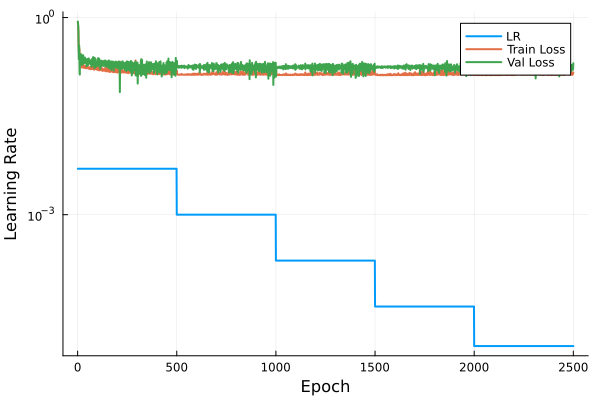

In [195]:
epochs = 1:length(lr_trace)

plot(epochs, lr_trace, yscale=:log10, xlabel="Epoch", ylabel="Learning Rate", label="LR", lw=2, legend=:topright)
plot!(epochs, train_loss_trace, label="Train Loss", lw=2)
plot!(epochs, val_loss_trace, label="Val Loss", lw=2)
# savefig(p, "lr_loss_curves.png")
# plot(epochs, grad_trace, xlabel="Epoch", ylabel="Gradient Norm", label="Grad", lw=2)

In [196]:
expr_name = "Xyl-6s5r1c-06"
fig_path = string("./results_catalyst/", expr_name, "/figs")
ckpt_path = string("./results_catalyst/", expr_name, "/checkpoint")
@load string(ckpt_path, "/mymodel.bson") p opt l_loss_train l_loss_val list_grad iter

#p[9] = -2
p_cutoff = 0.0

display_p(p)

for i_exp = 1:n_exp
    cbi(p, i_exp)
end

loss_epoch = zeros(Float64, n_exp);
for i_exp = 1:n_exp
    loss_epoch[i_exp] = loss_neuralode(p, i_exp)
end
loss_train = mean(loss_epoch[l_train])
loss_val = mean(loss_epoch[l_val])
loss_train, loss_val


 species (column) reaction (row)
w_in | w_cat_in | Ea | b | lnA | w_out | w_cat_out
5×15 Matrix{Float64}:
 -0.0  1.07  0.12  0.0   0.0  0.01  190.85  0.22  24.72   0.0  -1.07  -0.12   1.19  0.0   0.0
  0.3  0.0   0.1   0.0   0.0  0.04  200.0   0.03  19.21  -0.3   0.02  -0.1    0.26  0.12  0.0
 -0.0  0.06  1.24  0.0   0.0  0.0   163.42  0.25  24.86   0.0  -0.06  -1.24   1.13  0.16  0.0
  1.1  0.0   0.0   0.0   0.0  0.08  134.09  0.31  26.37  -1.1   0.03   0.01   0.67  0.4   0.0
 -0.0  0.0   0.0   1.09  0.0  0.05  166.59  0.39  29.44   0.0   0.15   0.27  -1.09  0.68  0.0



(0.21372444730131648, 0.07330790765801266)

In [ ]:
# Assuming l_exp_info contains temperature data in the first column
# and reaction rates are calculated from your model

# Function to calculate reaction rates based on temperature
function calculate_reaction_rates(T_list, p)
    reaction_rates = zeros(length(T_list))
    
    for (i, T) in enumerate(T_list)
        # Example: Modified Arrhenius equation
        A = exp(p[1])  # Pre-exponential factor (lnA)
        Ea = p[2]      # Activation energy
        b = p[3]       # Additional parameter for modification
        R = 8.314      # Universal gas constant in J/(mol*K)
        
        # Calculate reaction rate using modified Arrhenius equation
        reaction_rates[i] = A * exp(-Ea / (R * T)) * (1 + b * T)  # Example modification
    end
    
    return reaction_rates
end

# Extract temperatures from l_exp_info
T_list = l_exp_info[:, 1]  # Assuming first column contains temperatures

# Calculate reaction rates for the given temperatures
reaction_rates = calculate_reaction_rates(T_list, p)

# Plotting the results
plt = plot(T_list, reaction_rates, marker=:o, linestyle =:solid, color=:blue,
           xlabel="Temperature (K)", ylabel="Reaction Rate (mol/L·s)",
           title="Reaction Rate vs Temperature",
           legend=:topright)

# Save or display the plot
savefig(plt, string(fig_path, "/reaction_rate_vs_temp.png"))
display(plt)

Here’s a simple explanation for your code:

## What the Code Does

Your code takes a list of temperatures and uses a formula to calculate how fast a chemical reaction happens at each temperature. Then, it makes a picture (a plot) showing how the reaction speed changes with temperature.

## How It Works

- It gets the temperatures from your data list.
- For each temperature, it uses a special equation to find out how fast the reaction goes. This equation (called the “modified Arrhenius equation”) needs three recipe ingredients ("A", "Ea", and "b") and a special constant (R = 8.314).
- Then, it adds a point to a line on a graph.
- The graph's x-axis is temperature, and the y-axis is how fast the reaction happens.
- Finally, it saves and shows you the graph so you can see the trend.

## Visualizing the Process

Think of it like:
- You have temperatures written down (like 300, 350, 400...).
- For each temperature, you figure out how fast your reaction happens—like counting how many popcorns pop in a certain time at each microwave power level.
- You make a dot on the graph for each temperature and reaction speed.
- You get a picture that shows you: as temperature changes, does the reaction speed up or slow down?

This helps chemists easily see patterns in their experiments.

In [ ]:
# pyplot()
plot_loss(l_loss_train, l_loss_val; yscale = :log10)

Your code creates a plot to visualize how the training and validation losses change while your model learns.

## What It Does

- The function `plot_loss(l_loss_train, l_loss_val; yscale = :log10)` draws two lines—one for your model’s training loss and one for the validation loss—so you can see how they go down (or up) as training progresses.
- The `yscale = :log10` part makes the vertical axis logarithmic, which helps you see big and small changes in loss values more clearly.

## How It Works

- `l_loss_train` is a list with your model’s loss values on the training data at each step or epoch.
- `l_loss_val` is the same, but for your validation data (data the model hasn’t seen during training).
- Both lists are plotted against the number of steps/epochs.
- Using a log scale means the graph will show details even when the losses are very small or decrease quickly.

## Why This Is Useful

- You can check if both losses are going down—if yes, your model learns well.
- If training loss drops but validation loss doesn’t, your model might be overfitting (memorizing instead of learning).

This kind of plot quickly tells you how well your model is learning and helps you spot training problems.

In [ ]:
function loss_neuralode_res(p)
    l_loss_exp = zeros(n_exp)
    for i_exp in 1:n_exp
        exp_data = l_exp_data[i_exp]
        pred = Array(pred_n_ode(p, i_exp, exp_data))
        masslist = sum(clamp.(@view(pred[1:end-1, :]), 0, Inf), dims = 1)'
        l_loss_exp[i_exp] = mae(masslist, @view(exp_data[1:length(masslist), 3]))
    end
    return l_loss_exp
end

This function is measuring “how wrong” your Neural ODE model is for each experiment by comparing predicted mass to experimental mass.

## What the function does

- It loops over all experiments and, for each one, runs the Neural ODE to get a prediction.[1][2]
- Then it computes a mean absolute error (MAE) between the predicted mass and the experimental mass for that experiment and stores that value.[3][4]

## Line-by-line in simple terms

- `l_loss_exp = zeros(n_exp)`: Make a list full of zeros to later store one loss value per experiment.  
- `for i_exp in 1:n_exp`: Go through each experiment one by one.  
- `exp_data = l_exp_data[i_exp]`: Take the data for the current experiment.  
- `pred = Array(pred_n_ode(p, i_exp, exp_data))`: Use the parameters `p` and the Neural ODE to predict how things change over time for this experiment.[2][1]
- `masslist = sum(clamp.(@view(pred[1:end-1, :]), 0, Inf), dims = 1)'`:  
  - Take all but the last row of `pred` (probably species masses or concentrations over time).  
  - Clamp them so nothing is negative (values below 0 become 0).[5][6]
  - Sum across rows to get total mass at each time.  
- `l_loss_exp[i_exp] = mae(masslist, @view(exp_data[1:length(masslist), 3]))`:  
  - Take the model’s total mass (`masslist`) and the experimental mass (column 3 of `exp_data`).  
  - Compute MAE = average of absolute differences between prediction and experiment.[4][3]
- `return l_loss_exp`: Give back the list of errors, one per experiment.  

## Explained like you are 5

- Imagine you have several experiments where you measure how heavy something is at different times.  
- Your Neural ODE is like a “guessing machine” that guesses those weights over time.[1][2]
- For each experiment, this function:
  - Gets the guesses from the machine.  
  - Makes sure the guesses are not negative (because negative weight makes no sense).[5]
  - Adds up all parts to get the total weight.  
  - Compares these guessed weights to the real measured weights and computes “how far off” they are on average.[3]
- At the end, you have a list saying: “Experiment 1 was this wrong, Experiment 2 was this wrong, …”.


In [ ]:
println("results after pruning")
maxiters = 1e5
p_cutoff = 0.0

This snippet is just announcing a new phase (“after pruning”) and resetting two control variables for the next optimization/training run.

## What each line does

- `println("results after pruning")` prints that message to the console and then moves to a new line, so you can clearly see where the “after pruning” results start in your logs.[1][2]

- `maxiters = 1e5` sets the maximum number of iterations (e.g. for an optimizer or training loop) to \(10^5 = 100{,}000\).  
  - This acts as a safety cap so any later solve/optimization routine that reads `maxiters` will not run forever.[3][4]

- `p_cutoff = 0.0` resets your pruning threshold to zero, meaning no additional parameters will be pruned in the following steps, or that you are now evaluating the already‑pruned model with a cutoff of 0.  

So, conceptually: you print a header, then say “allow up to 100k iterations” and “use a pruning cutoff of 0” for what comes next.

In [ ]:
loss_epoch = zeros(Float64, n_exp);
for i_exp = 1:n_exp
    loss_epoch[i_exp] = loss_neuralode(p, i_exp)
end
loss_train = mean(loss_epoch[l_train])
loss_val = mean(loss_epoch[l_val])
@printf(
    "Loss train: %.2f val: %.2f p_cutoff: %.2e",
    log10(loss_train),
    log10(loss_val),
    p_cutoff
)

display_p(p)

This code is computing how wrong the model is for this epoch (for each experiment), then averaging that error over train and validation sets, printing it in log-scale, and showing the current parameters.

## Step-by-step meaning

- `loss_epoch = zeros(Float64, n_exp);`  
  Makes a list (array) to store one loss value for each experiment, starting all at 0.  

- `for i_exp = 1:n_exp ... end`  
  Loops over all experiments. For each experiment `i_exp`, it calls `loss_neuralode(p, i_exp)` and stores that number in `loss_epoch[i_exp]`.  
  So after the loop, `loss_epoch` holds the loss per experiment for this epoch.[1][2]

- `loss_train = mean(loss_epoch[l_train])`  
  Takes only the experiments that belong to the training set (indices in `l_train`) and computes their average loss. This is the training loss for this epoch.[3][4]

- `loss_val = mean(loss_epoch[l_val])`  
  Same idea, but for the validation experiments (indices in `l_val`). This is the validation loss. Monitoring both helps detect overfitting or underfitting.[5][3]

## Printing the log-loss nicely

- `@printf("Loss train: %.2f val: %.2f p_cutoff: %.2e", log10(loss_train), log10(loss_val), p_cutoff)`  
  - `log10(loss_train)` and `log10(loss_val)` take the base‑10 logarithm of the losses so you see them on a log scale, which is easier to read when values are very small.[3]
  - `%.2f` prints each log-loss with 2 digits after the decimal (like `-3.45`).[6][7][8]
  - `%.2e` prints `p_cutoff` in scientific notation (like `1.23e-04`).[7][9][8]

So the printed line looks like:  
`Loss train: -3.45 val: -3.20 p_cutoff: 1.23e-04`  

## Final line

- `display_p(p)`  
  Calls a custom function `display_p` (probably your helper) to show the current parameter values `p` in a nice format.  

## Explained like you are 5

- You have many experiments.  
- For each experiment, you measure “how bad” the model’s guess is and write that number in a list.  
- Then you:
  - Average the “badness” for training experiments.  
  - Average the “badness” for validation experiments.  
- You print both numbers (in a squished log scale so they are easy to compare) and also show what settings (parameters `p`) the model is using right now.


In [ ]:
for i_exp in randperm(n_exp)
    cbi(p, i_exp)
end

This code is saying: “take all your experiments, shuffle them like cards, and then run them one by one in that random order.”[1][2]

## What each piece means

- `n_exp`: This is how many experiments you have, like saying you have 10 toys lined up.  
- `randperm(n_exp)`: This makes a list of the numbers from `1` to `n_exp`, but scrambled in a random order, for example `[3, 1, 4, 2]` if `n_exp = 4`.[2][1]
- `for i_exp in randperm(n_exp) ... end`: This loop says, “take each experiment index in that scrambled list, one after another.”[3][4]

## What `cbi(p, i_exp)` does conceptually

- `cbi` is some function (often a “callback”) that you wrote or that the library gave you.  
- `cbi(p, i_exp)` means: “do something with parameters `p` for experiment number `i_exp`,” like checking or updating training for that particular experiment.[5][6]

So in kid terms:  
- First, you put numbers 1 to `n_exp` in a hat and mix them up (`randperm`).  
- Then you pull them out one by one, and for each number you say “Hey `cbi`, play with experiment number this-number using `p`.”


In [ ]:
l_loss_exp = loss_neuralode_res(p)

`l_loss_exp = loss_neuralode_res(p)` means: “compute the loss for the NeuralODE with parameters `p`, and store that number in a box called `l_loss_exp`.”[1][2][3]

## Breaking it down

- `loss_neuralode_res` is a function that takes the parameters `p` of your model, solves the NeuralODE, compares its output with data, and returns a single number measuring how bad the prediction is (the loss).[2][1]
- Writing `l_loss_exp = ...` just says “take the number that comes out of this function call and save it into the variable `l_loss_exp` so it can be used later (for logging, gradients, etc.).”[3]

So in kid terms: `loss_neuralode_res(p)` is a machine that, given the model settings `p`, tells you “how wrong” the model is right now, and `l_loss_exp` is the notebook where you write that score down.[1][2]


In [ ]:
l_exp_data = []
l_exp_info = zeros(Float64, length(l_exp), 3)
for (i_exp, value) in enumerate(l_exp)
    filename = string("data_cat_new/expdata_no", string(value), ".txt")
    exp_data = Float64.(load_exp(filename))
    push!(l_exp_data, exp_data)
    l_exp_info[i_exp, 1] = exp_data[1, 2] # initial temperature, K
end
l_exp_info[:, 2] = readdlm("data_cat_new/beta.txt")[l_exp]
#l_exp_info[:, 3] = log.(readdlm("exp_data_cat3/ocen.txt")[l_exp] .+ llb)
l_exp_info[:, 3] = (readdlm("data_cat_new/cata_conc.txt")[l_exp]);

l_loss_exp = loss_neuralode_res(p)

conc_end = zeros(n_exp, ns)

This code is loading experimental datasets, building a small “info table” for each experiment, computing their losses, and preparing an array for final concentrations.

## Loading experiment data

- `l_exp_data = []` creates an empty list that will store the full time‑series data for each experiment.[1][2]
- `l_exp_info = zeros(Float64, length(l_exp), 3)` makes a matrix with one row per experiment and 3 columns to store summary info (like temperature, heating rate, catalyst concentration).[2]

## Loop over experiments

- `for (i_exp, value) in enumerate(l_exp)` loops over the experiment IDs in `l_exp`, giving both the index in the list (`i_exp`) and the experiment number (`value`).[3][4]
- `filename = string("exp_data_cat3/expdata_no", string(value), ".txt")` builds the filename for that experiment’s data file.  
- `exp_data = Float64.(load_exp(filename))` loads the text file and converts everything to `Float64`, giving a numeric matrix of experimental data.[5][6]
- `push!(l_exp_data, exp_data)` appends this matrix to `l_exp_data`, so `l_exp_data[i_exp]` becomes “all data for experiment i_exp”.[1][2]
- `l_exp_info[i_exp, 1] = exp_data[1, 2]` stores the initial temperature (from row 1, column 2 of the data) into column 1 of the info matrix for that experiment.  

## Filling extra info columns

- `l_exp_info[:, 2] = readdlm("exp_data_cat3/beta.txt")[l_exp]` reads a file with heating rates (beta) and picks only the rows for the experiments in `l_exp`, then stores them in column 2.[7][8][9]
- `l_exp_info[:, 3] = (readdlm("exp_data_cat3/cata_conc.txt")[l_exp]);` similarly reads catalyst concentrations and stores them in column 3.[8][7]
- The commented line with `log.(...) .+ llb` suggests you previously used a log‑transformed quantity instead.  

So after this, `l_exp_info` is a compact summary table:  
- Column 1: initial temperature.  
- Column 2: heating rate beta.  
- Column 3: catalyst concentration.  

## Computing losses and preparing output

- `l_loss_exp = loss_neuralode_res(p)` calls your earlier function to compute one loss value per experiment with current parameters `p`.  
- `conc_end = zeros(n_exp, ns)` allocates a matrix to later store final concentrations for each experiment (one row per experiment, one column per species).[2]

### Explained like you are 5

- You have many experiments, each saved in its own text file.  
- This code opens each file, remembers all the measurements, and also notes three key facts per experiment: the starting temperature, how fast you heat, and how much catalyst you used.  
- Then it checks how wrong your model is for each experiment (the losses) and gets a blank table ready to store the final amounts of each chemical later.


In [ ]:
# Plot TGA data
list_plt = []
for i_exp = 1:14
    T0, beta, cata_conc = l_exp_info[i_exp, :]
    exp_data = l_exp_data[i_exp]
    sol = pred_n_ode(p, i_exp, exp_data)
    Tlist = similar(sol.t)
    T0, beta, cata_conc = l_exp_info[i_exp, :]
    for (i, t) in enumerate(sol.t)
        Tlist[i] = getsampletemp(t, T0, beta)
    end

    conc_end[i_exp, :] .= sol[:, end]

    plt = plot(
        Tlist,
        exp_data[:, 3],
        seriestype = :scatter,
        label = "Exp-$i_exp",
        framestyle = :box,
    )
    plot!(
        plt,
        Tlist,
        sum(sol[1:end-1, :], dims = 1)',
        lw = 2,
        legend = false,
    )
    xlabel!(plt, "Temperature [K]")

    exp_cond = @sprintf("T0:%.0f K", T0)
    exp_cond *= @sprintf("\nbeta:%.0f K/min", beta)

    ann_loc = [0.2, 0.3]
    if i_exp in [6, 7, 14]
        ann_loc = [0.7, 0.4]
    end
    annotate!(plt, xlims(plt)[1] + (xlims(plt)[end] - xlims(plt)[1]) * ann_loc[1],
                   ylims(plt)[1] + (ylims(plt)[end] - ylims(plt)[1]) * ann_loc[2],
                   text(exp_cond, 11))

    ylabel!(plt, "Mass [-] (No. $i_exp)")
    ylims!(plt, (0.0, 1.0))
    plot!(
        plt,
        xtickfontsize = 11,
        ytickfontsize = 11,
        xguidefontsize = 12,
        yguidefontsize = 12,
    )

    push!(list_plt, plt)
end

This loop makes one TGA plot per experiment, showing measured mass and model‑predicted mass vs temperature, and annotates each plot with the experiment conditions.

## Building temperature and solution data

- For each experiment `i_exp`, the code reads its initial temperature `T0`, heating rate `beta`, and catalyst concentration `cata_conc` from `l_exp_info`, and its full experimental time series from `l_exp_data[i_exp]`.  
- `sol = pred_n_ode(p, i_exp, exp_data)` runs the Neural ODE model to get predicted species amounts over time; `sol.t` holds the times, and `sol[:, end]` is the final state used to fill `conc_end[i_exp, :]`.  
- `Tlist` is created to have the same shape as `sol.t`, then filled in the inner loop using `getsampletemp(t, T0, beta)` so each time point is converted to its corresponding temperature, building the x‑axis for the TGA plot.[1][2]

## Plotting experimental vs model TGA curves

- First `plt = plot(Tlist, exp_data[:, 3], seriestype = :scatter, label = "Exp-$i_exp", framestyle = :box)` makes a scatter plot of experimental mass (column 3) vs temperature for this experiment.[3][1]
- Then `plot!(plt, Tlist, sum(sol[1:end-1, :], dims = 1)', lw = 2, legend = false)` overlays the model prediction: it sums all species except the last across rows at each time, giving total mass vs temperature as a smooth line.  
- `xlabel!(plt, "Temperature [K]")` and `ylabel!(plt, "Mass [-] (No. $i_exp)")` label the axes, while `ylims!(plt, (0.0, 1.0))` fixes the y‑axis between 0 and 1, as is common for normalized TGA mass.[4][1]

## Adding experiment conditions as text

- `exp_cond` is a multi‑line string built with `@sprintf("T0:%.0f K", T0)` and `@sprintf("\nbeta:%.0f K/min", beta)` to show initial temperature and heating rate in a neat format.[5][3]
- `ann_loc` defines a relative position inside the plot window (e.g. `[0.2, 0.3]` means 20% across, 30% up); for certain experiments `[6, 7, 14]` this is changed to `[0.7, 0.4]` to avoid overlapping the data.  
- `annotate!` converts that relative location into actual x,y coordinates using `xlims(plt)` and `ylims(plt)` and then draws the text `exp_cond` at that point on the plot.[6][7]

## Styling and collecting the plots

- The `plot!` call with `xtickfontsize`, `ytickfontsize`, `xguidefontsize`, and `yguidefontsize` just makes ticks and labels readable for all the small subplots.[1][3]
- `push!(list_plt, plt)` saves each subplot in `list_plt`, so later you can arrange them in a grid or save them all together (e.g. `plot(list_plt..., layout=(4,4))`).  

### Explained like you are 5

- For each experiment, the code turns time into temperature and asks your model to guess how the mass changes as it heats up.  
- It draws dots for the real measured mass and a smooth line for the model’s guess on the same temperature axis, then writes the starting temperature and heating rate inside the picture.  
- At the end, you get a bunch of small pictures, each showing “this is what the experiment did” and “this is what the model thinks” for that experiment.


In [ ]:
plt_all = plot(list_plt..., layout = (7, 2))
plot!(plt_all, size = (800, 1200))
png(plt_all, string(fig_path, "/TGA_mass_summary"))

In [ ]:
# https://github.com/DENG-MIT/Biomass.jl/blob/main/backup/crnn_cellulose_ocen_test.jl
varnames = ["Cellu", "S2", "S3", "Vola"]
for i_exp in 1:n_exp
    T0, beta, ocen = l_exp_info[i_exp, :]
    exp_data = l_exp_data[i_exp]
    sol = pred_n_ode(p, i_exp, exp_data)
    Tlist = similar(sol.t)
    T0, beta, ocen = l_exp_info[i_exp, :]
    for (i, t) in enumerate(sol.t)
        Tlist[i] = getsampletemp(t, T0, beta)
    end
    value = l_exp[i_exp]
    list_plt = []
    scale_factor = 1 ./ maximum(sol[:, :], dims=2)
    scale_factor .= 1.0
    plt = plot(Tlist, clamp.(sol[1, :], 0, Inf), label = varnames[1])
    for i in 2:ns
        if scale_factor[i] > 1.1
            _label =  @sprintf("%s x %.2e", varnames[i], scale_factor[i])
        else
            _label = varnames[i]
        end
        plot!(plt, Tlist, clamp.(sol[i, :], 0, Inf) * scale_factor[i], label = _label)
    end
    xlabel!(plt, "Temperature [K]");
    ylabel!(plt, "Mass (-)");
    plot!(plt, size=(350, 350), legend=:topleft, framestyle=:box)
    plot!(
        plt,
        xtickfontsize = 11,
        ytickfontsize = 11,
        xguidefontsize = 12,
        yguidefontsize = 12,
    )
    png(plt, string(fig_path, "/pred_S_exp_$value"))
end

include("dataset.jl")
gr()

This code makes one plot per experiment showing how each species mass changes with temperature, then saves each plot as a PNG.

## Core idea

- For every experiment, you:  
  - Run the Neural ODE to get species profiles over time.  
  - Convert time to temperature.  
  - Plot each species’ mass vs temperature.  
  - Save that figure to disk.

## Step by step

- `varnames = ["Cellu", "S2", "S3", "Vola"]` gives human‑readable names to your 4 species (indices 1…ns).  
- `for i_exp in 1:n_exp` loops over all experiments.  
- `T0, beta, ocen = l_exp_info[i_exp, :]` and `exp_data = l_exp_data[i_exp]` load the conditions and data for that experiment.  
- `sol = pred_n_ode(p, i_exp, exp_data)` runs the model; `sol[i, :]` is species `i` over time, `sol.t` is the time vector.  
- The inner `for (i, t) in enumerate(sol.t)` fills `Tlist` by mapping each time `t` to a temperature with `getsampletemp(t, T0, beta)`, so the x‑axis is temperature instead of time.

## Plotting each species

- `scale_factor = 1 ./ maximum(sol[:, :], dims=2)` would normalize curves, but `scale_factor .= 1.0` sets all of them to 1, so in practice there is no scaling.  
- `plt = plot(Tlist, clamp.(sol[1, :], 0, Inf), label = varnames[1])` plots the first species (Cellu) mass vs temperature, clamped so negatives go to 0.  
- The `for i in 2:ns` loop adds the remaining species on the same axes:  
  - If `scale_factor[i] > 1.1`, the label would show a “× factor”, otherwise just the name; with all `scale_factor[i] = 1.0` you always get plain names.  
  - `plot!(plt, Tlist, clamp.(sol[i, :], 0, Inf) * scale_factor[i], label = _label)` overlays each species curve.

## Styling and saving

- `xlabel!(plt, "Temperature [K]"); ylabel!(plt, "Mass (-)");` set axis labels.  
- `plot!(plt, size=(350, 350), legend=:topleft, framestyle=:box)` defines figure size, legend position, and a boxed frame.  
- The second `plot!` sets tick and label font sizes.  
- `value = l_exp[i_exp]` pulls the actual experiment ID, and  
  `png(plt, string(fig_path, "/pred_S_exp_$value"))` saves a PNG named by that ID into `fig_path`.  

## Explained like you are 5

- Imagine you have four ingredients in your sample.  
- As you heat it up, each ingredient’s amount goes up or down with temperature.  
- For every experiment, this code draws one picture with four lines: one line per ingredient, against temperature, and saves that picture in a folder.
